In [33]:
#****************************************************************************
# (C) Cloudera, Inc. 2020-2023
#  All rights reserved.
#
#  Applicable Open Source License: GNU Affero General Public License v3.0
#
#  NOTE: Cloudera open source products are modular software products
#  made up of hundreds of individual components, each of which was
#  individually copyrighted.  Each Cloudera open source product is a
#  collective work under U.S. Copyright Law. Your license to use the
#  collective work is as provided in your written agreement with
#  Cloudera.  Used apart from the collective work, this file is
#  licensed for your use pursuant to the open source license
#  identified above.
#
#  This code is provided to you pursuant a written agreement with
#  (i) Cloudera, Inc. or (ii) a third-party authorized to distribute
#  this code. If you do not have a written agreement with Cloudera nor
#  with an authorized and properly licensed third party, you do not
#  have any rights to access nor to use this code.
#
#  Absent a written agreement with Cloudera, Inc. (“Cloudera”) to the
#  contrary, A) CLOUDERA PROVIDES THIS CODE TO YOU WITHOUT WARRANTIES OF ANY
#  KIND; (B) CLOUDERA DISCLAIMS ANY AND ALL EXPRESS AND IMPLIED
#  WARRANTIES WITH RESPECT TO THIS CODE, INCLUDING BUT NOT LIMITED TO
#  IMPLIED WARRANTIES OF TITLE, NON-INFRINGEMENT, MERCHANTABILITY AND
#  FITNESS FOR A PARTICULAR PURPOSE; (C) CLOUDERA IS NOT LIABLE TO YOU,
#  AND WILL NOT DEFEND, INDEMNIFY, NOR HOLD YOU HARMLESS FOR ANY CLAIMS
#  ARISING FROM OR RELATED TO THE CODE; AND (D)WITH RESPECT TO YOUR EXERCISE
#  OF ANY RIGHTS GRANTED TO YOU FOR THE CODE, CLOUDERA IS NOT LIABLE FOR ANY
#  DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, PUNITIVE OR
#  CONSEQUENTIAL DAMAGES INCLUDING, BUT NOT LIMITED TO, DAMAGES
#  RELATED TO LOST REVENUE, LOST PROFITS, LOSS OF INCOME, LOSS OF
#  BUSINESS ADVANTAGE OR UNAVAILABILITY, OR LOSS OR CORRUPTION OF
#  DATA.
#
# #  Author(s): Paul de Fusco
#***************************************************************************/

## PLEASE USER JUPYTERLAB - Python 3.12 and SPARK 3.2+ RUNTIME for this demo
- Use Resources atleast vCPU : 4 and Memory 8GB

In [1]:
!pip3 install -q open-inference-openapi 
#!pip3 install httpx uvicorn

### Authentication and Domain Details your CAII Inference endpoint call
All Calls to the Inference Service will be authenticated with the Knox Token. You can find more details or documentation [here](https://docs.cloudera.com/machine-learning/cloud/ai-inference/topics/ml-caii-authentication.html)

*Two quick tips for you to generate workload authentication*
- Use the CDP CLI command : 
```
cdp iam generate-workload-auth-token --workload-name DE 
```
- Alternatively,  use the Cloudera AI Inference service for details on end point and domain as shown below
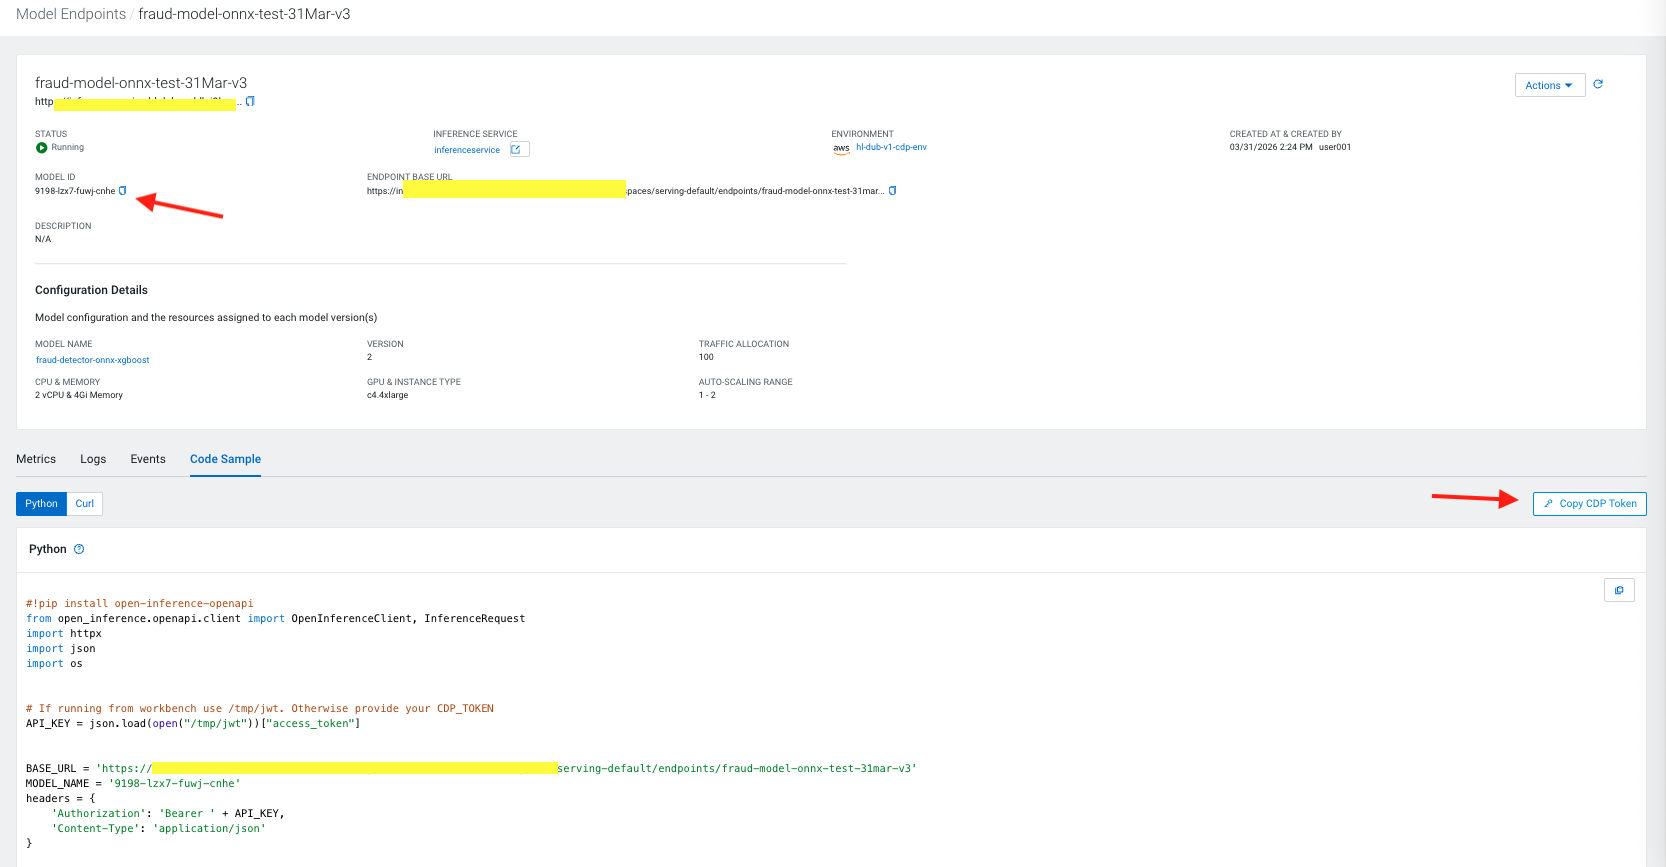
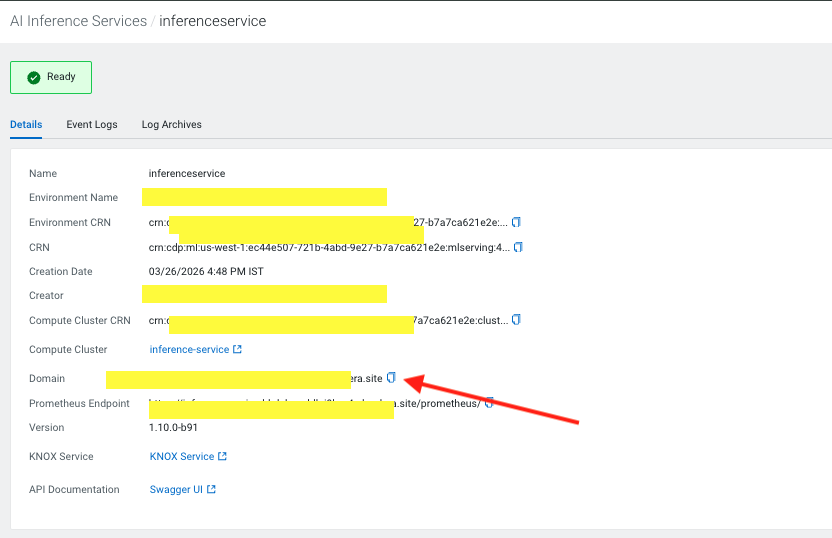

In [ ]:
import os
myToken = "your-model-api-key" # use instructions above
modelId = "y14y-gar8-xbo3-m3x7"  # Fetch from Model Registry

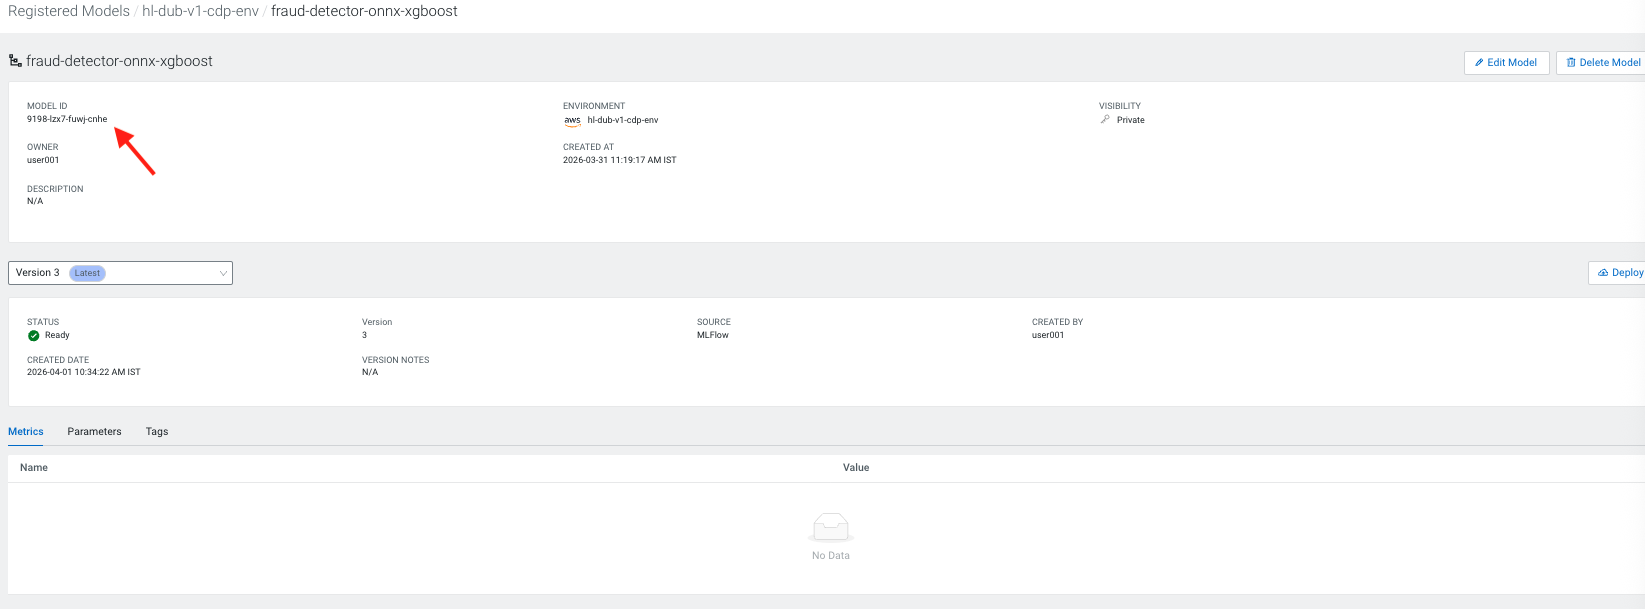

In [7]:
import json
import httpx

#JWT = json.load(open("/tmp/jwt"))["access_token"]
JWT = myToken
headers = {'Authorization': 'Bearer ' + JWT,
           'Content-Type': 'application/json'}

httpx_client = httpx.Client(headers=headers)

In [8]:
# Wait for the endpoint to be ready
CAII_DOMAIN_URL = 'https://inferenceservice.hl-dub-v.oldk-i9ly.a4.cloudera.site'
CAII_MODEL_NAME =  "fraud-clf-onnx-xgboost-user020"

## SKIP Next STEP If your Model Already is deployed. else you will get an error

In [10]:
## Deployment of End point, No need for this if you have an endpoint already
deploy_payload = {
 "namespace": "serving-default",
 "name": CAII_MODEL_NAME,
 "source": {
   "registry_source": {
      "model_id": modelId,
      "version": 1
    }
  },
 "resources": {
    "req_cpu": "2",
    "req_memory": "4Gi"
  },
  "api_standard": "oip",
  "has_chat_template": False,
  "metric_format": "triton",
  "task": "INFERENCE",
  "instance_type": "m5.12xlarge",
 "autoscaling": {
    "min_replicas": "1",
    "max_replicas": "2"
  }
}

r = httpx_client.post(CAII_DOMAIN_URL+'/api/v1alpha1/deployEndpoint', json=deploy_payload)
r

<Response [200 OK]>

In [11]:

describe_payload = {
    "namespace": "serving-default",
    "name": CAII_MODEL_NAME
}

r = httpx_client.post(CAII_DOMAIN_URL+'/api/v1alpha1/describeEndpoint', json=describe_payload)
status = r.json()['status']
response = json.dumps(r.json(), indent=2)
print(response)

# Want target_model_state to get to 'Loaded'
status['target_model_state']

{
  "namespace": "serving-default",
  "name": "fraud-clf-onnx-xgboost-user020",
  "url": "",
  "conditions": [
    {
      "type": "IngressReady",
      "status": "Unknown",
      "severity": "",
      "last_transition_time": "1775031049",
      "reason": "Predictor ingress not created",
      "message": ""
    },
    {
      "type": "LatestDeploymentReady",
      "status": "Unknown",
      "severity": "Info",
      "last_transition_time": "1775031049",
      "reason": "PredictorConfigurationReady not ready",
      "message": ""
    },
    {
      "type": "PredictorConfigurationReady",
      "status": "Unknown",
      "severity": "Info",
      "last_transition_time": "1775031050",
      "reason": "",
      "message": ""
    },
    {
      "type": "PredictorReady",
      "status": "Unknown",
      "severity": "",
      "last_transition_time": "1775031050",
      "reason": "RevisionMissing",
      "message": "Configuration \"fraud-clf-onnx-xgboost-user020-predictor\" is waiting for a Rev

'Pending'

In [10]:
#!pip3 install open-inference-openapi tritonclient[all]

In [12]:
# Get BASE_URL of the model endpoint. For predictive models, this is the endpoint URL preceding '/v2'
from urllib.parse import urlparse

r = httpx_client.post(CAII_DOMAIN_URL+'/api/v1alpha1/describeEndpoint', json=describe_payload)
url = r.json()['url']

# Remove last 4 path components to get the base url
parsed_url = urlparse(url)
path_parts = parsed_url.path.split("/")
new_path = "/".join(path_parts[:-4])
modified_url = parsed_url._replace(path=new_path).geturl()
modified_url

'https://inferenceservice.hl-dub-v.oldk-i9ly.a4.cloudera.site/namespaces/serving-default/endpoints/fraud-clf-onnx-xgboost-user020'

In [13]:
from open_inference.openapi.client import OpenInferenceClient, InferenceRequest
import httpx
import requests
import json

httpx_client = httpx.Client(headers=headers)
client = OpenInferenceClient(base_url=modified_url, httpx_client=httpx_client)
client.check_server_readiness()
metadata = client.read_model_metadata(modelId)
metadata_str = json.dumps(json.loads(metadata.json()), indent=2)
print(metadata_str)

{
  "name": "y14y-gar8-xbo3-m3x7",
  "versions": [
    "1"
  ],
  "platform": "onnxruntime_onnx",
  "inputs": [
    {
      "name": "input",
      "datatype": "FP32",
      "shape": [
        -1,
        15
      ]
    }
  ],
  "outputs": [
    {
      "name": "probabilities",
      "datatype": "FP32",
      "shape": [
        -1,
        2
      ]
    },
    {
      "name": "label",
      "datatype": "INT64",
      "shape": [
        -1,
        1
      ]
    }
  ]
}


## Ensure that the model endpoints are available before you start calling


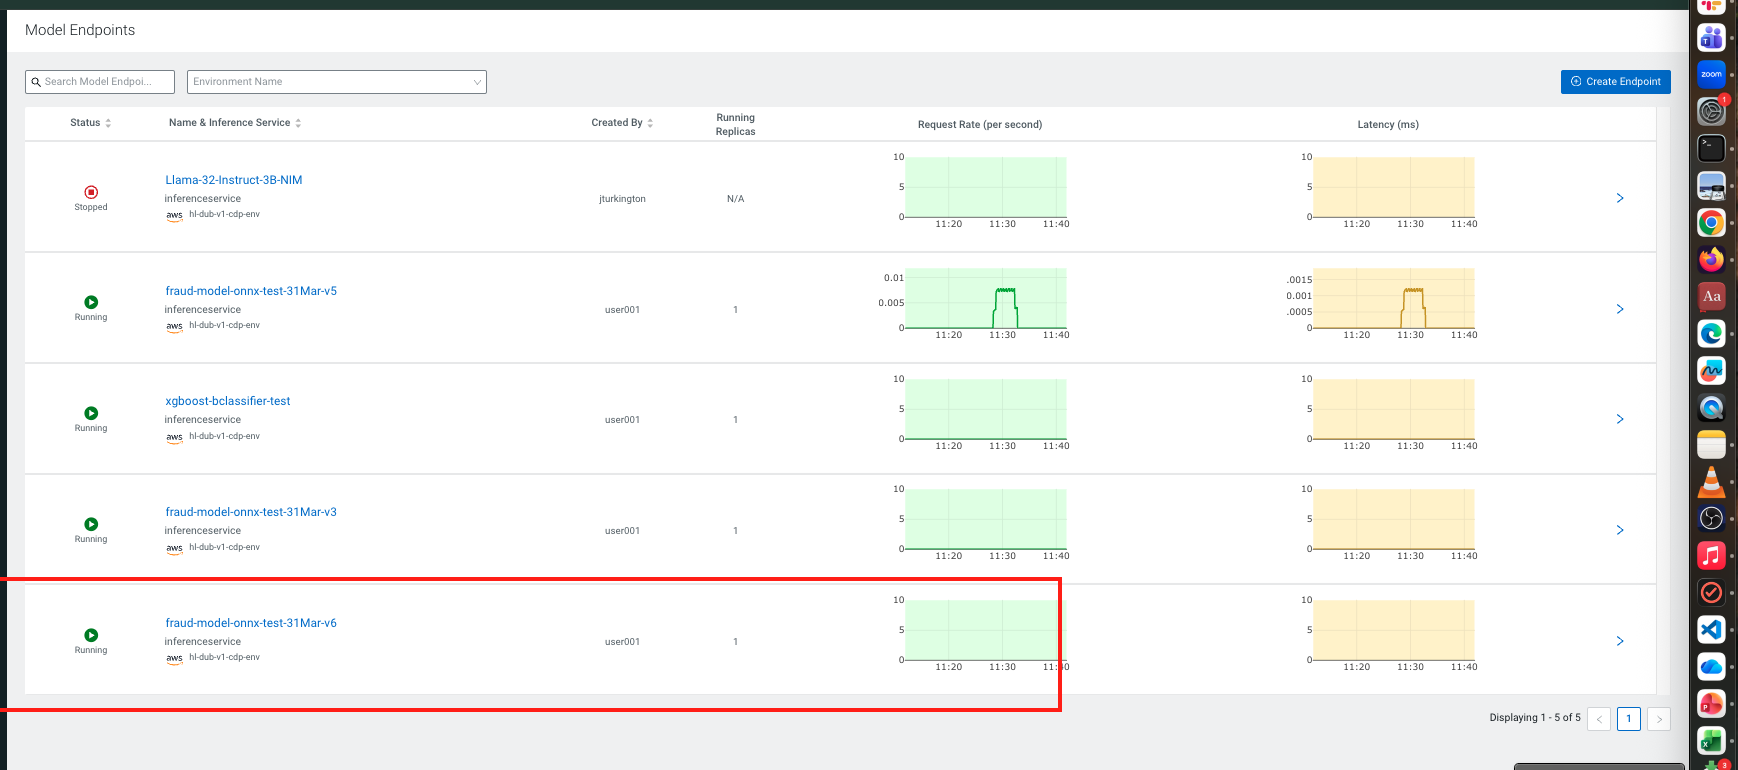


### Inferencing your Deployed Endpoint 
- Step 1: Get the Data that you want to pass as payload
- Step 2 : Call the Inference Endpoints

In [ ]:
import os, warnings, sys, logging
import mlflow
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
import mlflow.sklearn
from xgboost import XGBClassifier
from datetime import date
import cml.data_v1 as cmldata
import pyspark.pandas as ps
from pyspark import SparkContext
SparkContext.setSystemProperty('spark.executor.cores', '4')
SparkContext.setSystemProperty('spark.executor.memory', '8g')

USERNAME = os.environ["PROJECT_OWNER"]
DBNAME = os.environ["DBNAME_PREFIX"]+"_"+USERNAME
CONNECTION_NAME = os.environ["SPARK_CONNECTION_NAME"]

DATE = date.today()
EXPERIMENT_NAME = "xgb-cc-fraud-{0}".format(USERNAME)

mlflow.set_experiment(EXPERIMENT_NAME)

conn = cmldata.get_connection(CONNECTION_NAME)
spark = conn.get_spark_session()

df_from_sql = ps.read_table('{0}.transactions_{1}'.format(DBNAME, USERNAME))
df = df_from_sql.to_pandas()
#df = df.drop(columns=["job"])

# test_size = 0.3
# X_train, X_test, y_train, y_test = train_test_split(df.drop("fraud_trx", axis=1), df["fraud_trx"], test_size=test_size)
y = df["fraud_trx"]
X = df.drop(columns=["fraud_trx"])
X.columns = ['f' + str(i) for i in range(len(X.columns))]

test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

In [14]:
print(X_train.iloc[0].values.tolist())

[64.0, 26299.0, 90476.0078125, 639794.0, 37520.01171875, 322256.0, 109950.0078125, 468704.0, 1082.010009765625, 212299.015625, 4961.009765625, 180.0, 28.0, 22517.009765625, 0.0]


In [15]:
import time
## get the response from the payload 
data = X_train.iloc[0].values.tolist()
# if spark processing is stuck just use 
data = [64.0, 26299.0, 90476.0078125, 639794.0, 37520.01171875, 322256.0, 109950.0078125, 468704.0, 1082.010009765625, 212299.015625, 4961.009765625, 180.0, 28.0, 22517.009765625, 0.0]

payload = {
    "parameters": {
        "content_type": "pd"
    },
    "inputs": [
        {
            "name": "input",
            "datatype": "FP32",
            "shape": [1, 15],
            "data": data
        }
    ]
}
start = time.time()
pred = client.model_infer(
    modelId,
    request=InferenceRequest(
        inputs=payload["inputs"]
    ),
)

end = time.time()

json_resp_str = json.dumps(json.loads(pred.json()), indent=2)
print(json_resp_str)
print(f"latency={end-start}")

{
  "model_name": "9198-lzx7-fuwj-cnhe",
  "model_version": "3",
  "outputs": [
    {
      "name": "label",
      "shape": [
        1,
        1
      ],
      "datatype": "INT64",
      "data": [
        0.0
      ]
    },
    {
      "name": "probabilities",
      "shape": [
        1,
        2
      ],
      "datatype": "FP32",
      "data": [
        0.9998667240142822,
        0.00013327598571777344
      ]
    }
  ]
}
latency=0.03323769569396973


In [16]:
#batch inferencing

In [17]:
import time
import json
import random
import math
from open_inference.openapi.client import InferenceRequest

# 1. Configuration
MAX_BATCH_SIZE = 4  # The limit defined by your endpoint error
num_total_records = random.randint(5, 20)
print(f"Processing {num_total_records} total records in chunks of {MAX_BATCH_SIZE}...")

# 2. Get the random sample from X_test
full_sample_df = X_test.sample(n=num_total_records)
num_features = full_sample_df.shape[1]

all_predictions = []
start_total = time.time()

# 3. Loop through the dataframe in chunks of 4
for i in range(0, num_total_records, MAX_BATCH_SIZE):
    # Slice the dataframe for the current batch
    batch_df = full_sample_df.iloc[i : i + MAX_BATCH_SIZE]
    current_batch_size = len(batch_df)
    
    # Flatten data for this specific batch
    batch_data = batch_df.values.flatten().tolist()
    
    print(f"  Sending batch {i//MAX_BATCH_SIZE + 1} ({current_batch_size} records)...")
    
    try:
        pred = client.model_infer(
            modelId,
            request=InferenceRequest(
                inputs=[{
                    "name": "input",
                    "datatype": "FP32",
                    "shape": [current_batch_size, num_features],
                    "data": batch_data
                }]
            ),
        )
        # Store the individual results
        all_predictions.append(json.loads(pred.json()))
        
    except Exception as e:
        print(f"  ❌ Error in batch starting at index {i}: {e}")

end_total = time.time()

# 4. Final Summary
print("-" * 30)
print(f"Successfully processed {len(all_predictions)} batches.")
print(f"Total time taken: {end_total - start_total:.4f}s")

# Optionally print the first result to verify
if all_predictions:
    print("\nFirst Batch Result Snippet:")
    print(json.dumps(all_predictions[0], indent=2))

Processing 19 total records in chunks of 4...
  Sending batch 1 (4 records)...
  Sending batch 2 (4 records)...
  Sending batch 3 (4 records)...
  Sending batch 4 (4 records)...
  Sending batch 5 (3 records)...
------------------------------
Successfully processed 5 batches.
Total time taken: 0.0594s

First Batch Result Snippet:
{
  "model_name": "9198-lzx7-fuwj-cnhe",
  "model_version": "3",
  "outputs": [
    {
      "name": "label",
      "shape": [
        4,
        1
      ],
      "datatype": "INT64",
      "data": [
        0.0,
        1.0,
        1.0,
        1.0
      ]
    },
    {
      "name": "probabilities",
      "shape": [
        4,
        2
      ],
      "datatype": "FP32",
      "data": [
        0.9993109703063965,
        0.0006890296936035156,
        1.9788742065429688e-05,
        0.9999802112579346,
        0.0001710653305053711,
        0.9998289346694946,
        0.00019174814224243164,
        0.9998082518577576
      ]
    }
  ]
}


### See the Details in Inference Monitoring as below 

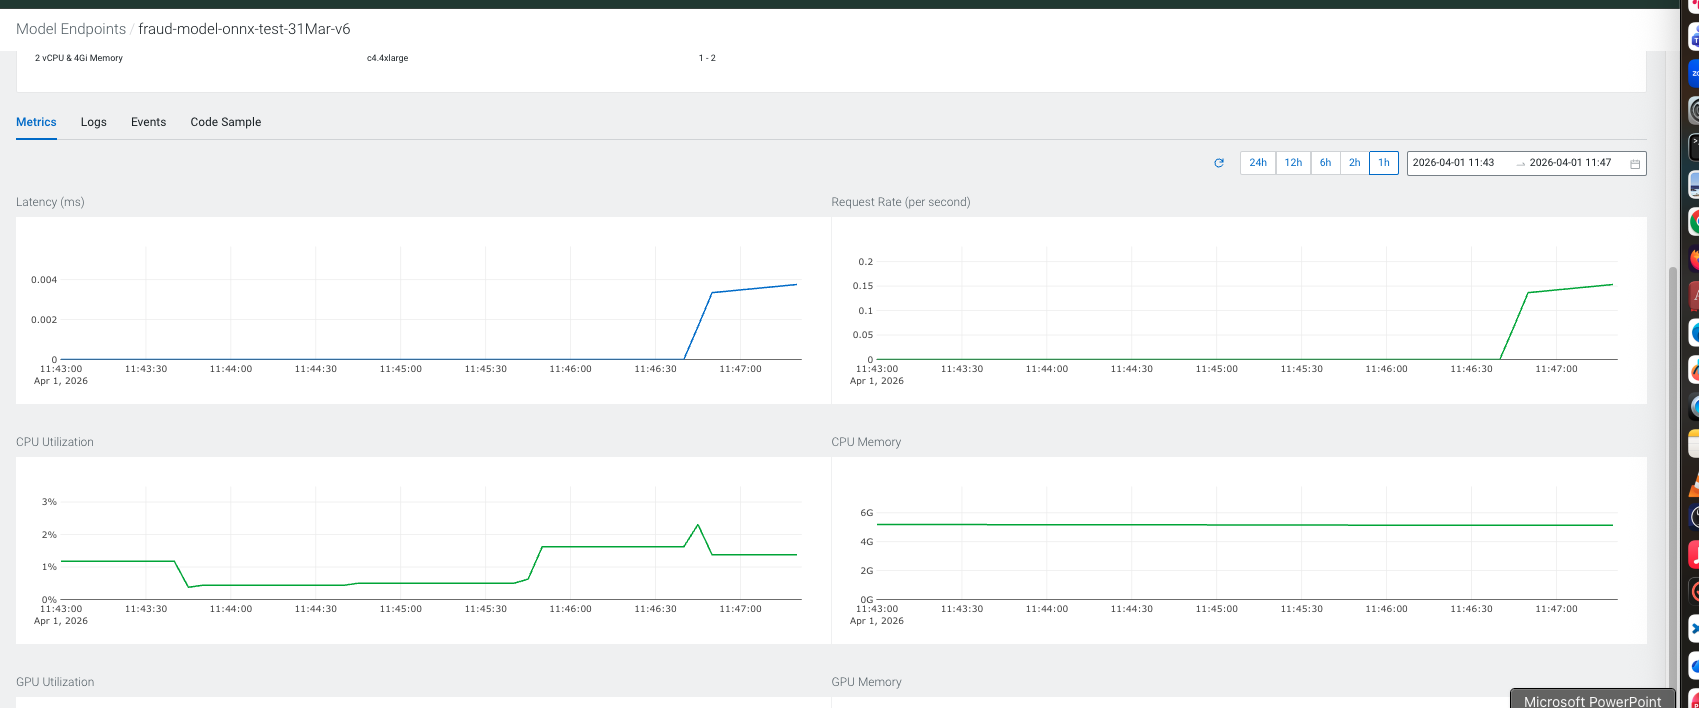